### 1.4.3.2. Newton's Law of Cooling

$$
\frac{dT}{dt} = k\,(T - T_m), \quad T(0) = T_0 \;\Longrightarrow\; T(t) = T_m + (T_0 - T_m)\,e^{kt} .
$$

**Explanation:**

Newton's law of cooling/warming says the temperature of an object changes at a rate proportional to the gap between the object and its surrounding (ambient) temperature $T_m$. The resulting [linear](../02_First_Order_Equations/04_linear_first_order_equations.ipynb) equation $T' = k(T - T_m)$ has solution $T(t) = T_m + (T_0 - T_m)e^{kt}$ with $k < 0$, so the object approaches $T_m$ exponentially but never exactly reaches it in finite time. This first-order relaxation toward a setpoint is the prototype of a stable [first-order system](../02_First_Order_Equations/02_autonomous_equations_and_stability.ipynb) in process control.

**Properties:**
- The ambient temperature $T_m$ is the stable equilibrium: $T(t) \to T_m$ as $t \to \infty$.
- Two temperature readings determine both unknowns: $T_0$ fixes the constant and a later reading fixes $k$.

**Numerical Example:**

A cake leaves the oven at $300^\circ$F into a $70^\circ$F room; after 3 minutes it is $200^\circ$F. Solve

$$
\frac{dT}{dt} = k(T - 70), \quad T(0) = 300, \quad T(3) = 200 .
$$

Separate and integrate:

$$
\frac{dT}{T - 70} = k\,dt \;\Rightarrow\; \ln|T - 70| = kt + c_1 \;\Rightarrow\; T = 70 + c_2 e^{kt}.
$$

Apply $T(0) = 300$: $\;300 = 70 + c_2 \Rightarrow c_2 = 230$, so $T = 70 + 230e^{kt}$. Apply $T(3) = 200$:

$$
200 = 70 + 230 e^{3k} \;\Rightarrow\; e^{3k} = \frac{130}{230} = \frac{13}{23} \;\Rightarrow\; k = \tfrac{1}{3}\ln\tfrac{13}{23} \approx -0.19018 .
$$

Therefore

$$
T(t) = 70 + 230\,e^{-0.19018\,t},
$$

which tends to room temperature $70^\circ$F as $t \to \infty$ (about half an hour to get close).

In [1]:
import sympy as sp

t, k = sp.symbols("t k")
T = sp.Function("T")

solution = sp.dsolve(sp.Eq(T(t).diff(t), k * (T(t) - 70)), T(t), ics={T(0): 300})
cooling_ratio = sp.Rational(200 - 70, 230)
cooling_constant = sp.log(cooling_ratio) / 3
temperature = solution.rhs.subs(k, cooling_constant)

print("T(t) =", solution.rhs)
print("from T(3)=200:  e^(3k) = (200-70)/230 =", cooling_ratio)
print("k = (1/3) ln(13/23) =", sp.N(cooling_constant, 5))
print("limit as t->oo      =", sp.limit(temperature, t, sp.oo))

T(t) = 230*exp(k*t) + 70
from T(3)=200:  e^(3k) = (200-70)/230 = 13/23
k = (1/3) ln(13/23) = -0.19018
limit as t->oo      = 70


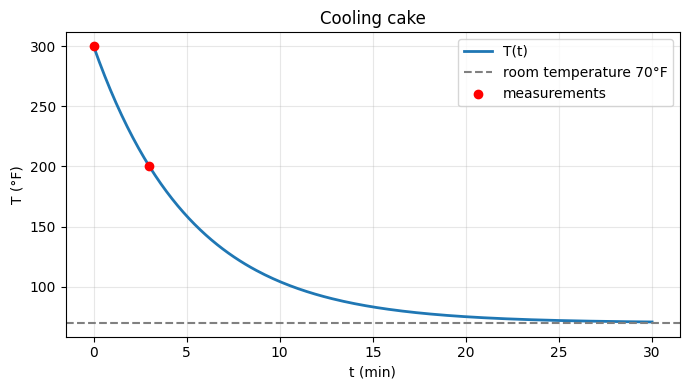

In [2]:
import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0, 30, 200)
temperature = 70 + 230 * np.exp(-0.19018 * time)

plt.figure(figsize=(7, 4))
plt.plot(time, temperature, linewidth=2, label="T(t)")
plt.axhline(70, color="gray", linestyle="--", label="room temperature 70°F")
plt.scatter([0, 3], [300, 200], color="red", zorder=5, label="measurements")
plt.xlabel("t (min)"); plt.ylabel("T (°F)"); plt.title("Cooling cake")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Growth and Decay](./01_growth_and_decay.ipynb) | [Next: Mixtures ➡️](./03_mixtures.ipynb)